In [1]:
import pandas as pd
import numpy as np

file_path = "../data/raw/india_air_quality/station_hour.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

C:\Users\HP\AppData\Local\Temp\ipykernel_46784\2765375237.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape: (2589083, 16)
  StationId             Datetime  PM2.5    PM10    NO    NO2    NOx    NH3  \
0     AP001  2017-11-24 17:00:00  60.50   98.00  2.35  30.80  18.25   8.50   
1     AP001  2017-11-24 18:00:00  65.50  111.25  2.70  24.20  15.07   9.77   
2     AP001  2017-11-24 19:00:00  80.00  132.00  2.10  25.18  15.15  12.02   
3     AP001  2017-11-24 20:00:00  81.50  133.25  1.95  16.25  10.23  11.58   
4     AP001  2017-11-24 21:00:00  75.25  116.00  1.43  17.48  10.43  12.03   

    CO    SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  0.1  11.85  126.40      0.1     6.10    0.10  NaN        NaN  
1  0.1  13.17  117.12      0.1     6.25    0.15  NaN        NaN  
2  0.1  12.08   98.98      0.2     5.98    0.18  NaN        NaN  
3  0.1  10.47  112.20      0.2     6.72    0.10  NaN        NaN  
4  0.1   9.12  106.35      0.2     5.75    0.08  NaN        NaN  
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xy

In [2]:
print(df.columns.tolist())

['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [4]:
stations = pd.read_csv("../data/raw/india_air_quality/stations.csv")

print("Shape:", stations.shape)
print(stations.head())
print(stations.columns.tolist())

Shape: (230, 5)
  StationId                                     StationName  \
0     AP001                  Secretariat, Amaravati - APPCB   
1     AP002  Anand Kala Kshetram, Rajamahendravaram - APPCB   
2     AP003                      Tirumala, Tirupati - APPCB   
3     AP004                 PWD Grounds, Vijayawada - APPCB   
4     AP005          GVM Corporation, Visakhapatnam - APPCB   

                City           State  Status  
0          Amaravati  Andhra Pradesh  Active  
1  Rajamahendravaram  Andhra Pradesh     NaN  
2           Tirupati  Andhra Pradesh     NaN  
3         Vijayawada  Andhra Pradesh     NaN  
4      Visakhapatnam  Andhra Pradesh  Active  
['StationId', 'StationName', 'City', 'State', 'Status']


In [5]:
mumbai_stations = stations[
    stations["City"].str.lower() == "mumbai"
].copy()

print("Mumbai stations:")
print(mumbai_stations)

print("\nNumber of Mumbai stations:",
      mumbai_stations["StationId"].nunique())

Mumbai stations:
    StationId                                        StationName    City  \
139     MH005                              Bandra, Mumbai - MPCB  Mumbai   
140     MH006                       Borivali East, Mumbai - MPCB  Mumbai   
141     MH007  Chhatrapati Shivaji Intl. Airport (T2), Mumbai...  Mumbai   
142     MH008                              Colaba, Mumbai - MPCB  Mumbai   
143     MH009                               Kurla, Mumbai - MPCB  Mumbai   
144     MH010                               Powai, Mumbai - MPCB  Mumbai   
145     MH011                                Sion, Mumbai - MPCB  Mumbai   
146     MH012                          Vasai West, Mumbai - MPCB  Mumbai   
147     MH013                     Vile Parle West, Mumbai - MPCB  Mumbai   
148     MH014                               Worli, Mumbai - MPCB  Mumbai   

           State  Status  
139  Maharashtra  Active  
140  Maharashtra  Active  
141  Maharashtra  Active  
142  Maharashtra  Active  
143  Mahara

In [6]:
selected_stations = [
    "MH010",  # Powai
    "MH014",  # Worli
    "MH011",  # Sion
    "MH008",  # Colaba
    "MH009",  # Kurla
    "MH007"   # Airport T2
]

mumbai_selected = df[
    df["StationId"].isin(selected_stations)
].copy()

print("Shape:", mumbai_selected.shape)
print(mumbai_selected["StationId"].value_counts())

Shape: (55446, 16)
MH007    9423
MH010    9422
MH009    9370
MH014    9255
MH011    9035
MH008    8941
Name: StationId, dtype: int64


In [7]:
print(mumbai_selected["Datetime"].head())
print(mumbai_selected["Datetime"].tail())

1755204    2019-06-04 10:00:00
1755205    2019-06-04 11:00:00
1755206    2019-06-04 12:00:00
1755207    2019-06-04 13:00:00
1755208    2019-06-04 14:00:00
Name: Datetime, dtype: object
1829528    2020-06-30 20:00:00
1829529    2020-06-30 21:00:00
1829530    2020-06-30 22:00:00
1829531    2020-06-30 23:00:00
1829532    2020-07-01 00:00:00
Name: Datetime, dtype: object


In [8]:
mumbai_selected["Datetime"] = pd.to_datetime(
    mumbai_selected["Datetime"],
    errors="coerce"
)

print(mumbai_selected["Datetime"].min())
print(mumbai_selected["Datetime"].max())

2019-06-04 10:00:00
2020-07-01 00:00:00


In [9]:
missing = (
    mumbai_selected
    .groupby("StationId")["PM2.5"]
    .apply(lambda x: x.isna().mean() * 100)
)

print(missing)

StationId
MH007    13.286639
MH008     8.321217
MH009    10.074707
MH010     2.621524
MH011     6.961815
MH014     4.721772
Name: PM2.5, dtype: float64


In [10]:
print(
    mumbai_selected["PM2.5"].isna().mean() * 100,
    "%"
)

7.670526277819861 %


In [11]:
important_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "NO",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3"
]

print(
    mumbai_selected[important_columns].isna().mean() * 100
)

PM2.5    7.670526
PM10     7.127656
NO2      6.671356
NO       4.443963
NOx      4.238358
NH3      4.849764
CO       5.035530
SO2      9.102550
O3       6.141110
dtype: float64


In [12]:
station = mumbai_selected[
    mumbai_selected["StationId"] == "MH010"
].sort_values("Datetime")

time_diff = station["Datetime"].diff()

print(time_diff.value_counts().head(10))

0 days 01:00:00    9421
Name: Datetime, dtype: int64


In [13]:
station_summary = (
    mumbai_selected
    .groupby("StationId")
    .agg(
        records=("Datetime", "count"),
        start=("Datetime", "min"),
        end=("Datetime", "max"),
        pm25_missing=("PM2.5", lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

print(station_summary)

  StationId  records               start        end  pm25_missing
0     MH007     9423 2019-06-04 10:00:00 2020-07-01     13.286639
1     MH008     8941 2019-06-24 12:00:00 2020-07-01      8.321217
2     MH009     9370 2019-06-06 15:00:00 2020-07-01     10.074707
3     MH010     9422 2019-06-04 11:00:00 2020-07-01      2.621524
4     MH011     9035 2019-06-20 14:00:00 2020-07-01      6.961815
5     MH014     9255 2019-06-11 10:00:00 2020-07-01      4.721772


In [14]:
output_path = "../data/processed/mumbai_pm25_raw.csv"

mumbai_selected.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../data/processed/mumbai_pm25_raw.csv


In [15]:
print("1. Shape:")
print(mumbai_selected.shape)

print("\n2. Station counts:")
print(mumbai_selected["StationId"].value_counts())

print("\n3. Station summary:")
print(station_summary)

print("\n4. Missing important columns:")
print(mumbai_selected[important_columns].isna().mean() * 100)

1. Shape:
(55446, 16)

2. Station counts:
MH007    9423
MH010    9422
MH009    9370
MH014    9255
MH011    9035
MH008    8941
Name: StationId, dtype: int64

3. Station summary:
  StationId  records               start        end  pm25_missing
0     MH007     9423 2019-06-04 10:00:00 2020-07-01     13.286639
1     MH008     8941 2019-06-24 12:00:00 2020-07-01      8.321217
2     MH009     9370 2019-06-06 15:00:00 2020-07-01     10.074707
3     MH010     9422 2019-06-04 11:00:00 2020-07-01      2.621524
4     MH011     9035 2019-06-20 14:00:00 2020-07-01      6.961815
5     MH014     9255 2019-06-11 10:00:00 2020-07-01      4.721772

4. Missing important columns:
PM2.5    7.670526
PM10     7.127656
NO2      6.671356
NO       4.443963
NOx      4.238358
NH3      4.849764
CO       5.035530
SO2      9.102550
O3       6.141110
dtype: float64


In [16]:
# Sort data by station and time
mumbai_selected = mumbai_selected.sort_values(
    ["StationId", "Datetime"]
).copy()

# Check consecutive missing PM2.5 sequences
def get_missing_runs(group):
    is_missing = group["PM2.5"].isna()

    # Identify groups of consecutive missing/non-missing values
    groups = is_missing.ne(is_missing.shift()).cumsum()

    runs = (
        group[is_missing]
        .groupby(groups)
        .size()
    )

    return runs


missing_runs = (
    mumbai_selected
    .groupby("StationId", group_keys=False)
    .apply(get_missing_runs)
)

print(missing_runs.describe())

count    513.000000
mean       8.290448
std       55.614250
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      809.000000
dtype: float64


In [17]:
# Get missing-run lengths for each station
all_runs = []

for station_id, group in mumbai_selected.groupby("StationId"):

    group = group.sort_values("Datetime")

    is_missing = group["PM2.5"].isna()

    # Identify consecutive sequences
    run_id = is_missing.ne(is_missing.shift()).cumsum()

    runs = (
        group[is_missing]
        .groupby(run_id)
        .size()
    )

    for length in runs:
        all_runs.append({
            "StationId": station_id,
            "missing_hours": length
        })

missing_runs_df = pd.DataFrame(all_runs)

print(missing_runs_df.head(20))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
   StationId  missing_hours
0      MH007             40
1      MH007              3
2      MH007              4
3      MH007            121
4      MH007             24
5      MH007             18
6      MH007              5
7      MH007              1
8      MH007              1
9      MH007              2
10     MH007              1
11     MH007              1
12     MH007             16
13     MH007              1
14     MH007              1
15     MH007              2
16     MH007              1
17     MH007              2
18     MH007             18
19     MH007             23


In [18]:
print(
    missing_runs_df["missing_hours"].describe()
)

count    513.000000
mean       8.290448
std       55.614250
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      809.000000
Name: missing_hours, dtype: float64


In [19]:
print(
    missing_runs_df["missing_hours"].value_counts().sort_index().head(20)
)

1     288
2     100
3      43
4      19
5       9
6       7
7       3
8       3
9       5
10      2
12      1
13      3
14      2
15      2
16      4
17      1
18      5
19      1
21      1
23      2
Name: missing_hours, dtype: int64


In [20]:
# Check timestamp gaps for every station

timestamp_gaps = []

for station_id, group in mumbai_selected.groupby("StationId"):

    group = group.sort_values("Datetime")

    differences = group["Datetime"].diff().dropna()

    gap_counts = differences.value_counts()

    print(f"\nStation: {station_id}")
    print(gap_counts.head(10))


Station: MH007
0 days 01:00:00    9422
Name: Datetime, dtype: int64

Station: MH008
0 days 01:00:00    8940
Name: Datetime, dtype: int64

Station: MH009
0 days 01:00:00    9369
Name: Datetime, dtype: int64

Station: MH010
0 days 01:00:00    9421
Name: Datetime, dtype: int64

Station: MH011
0 days 01:00:00    9034
Name: Datetime, dtype: int64

Station: MH014
0 days 01:00:00    9254
Name: Datetime, dtype: int64


In [21]:
print(missing_runs_df["missing_hours"].describe())
print(missing_runs_df["missing_hours"].value_counts().sort_index().head(20))

count    513.000000
mean       8.290448
std       55.614250
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      809.000000
Name: missing_hours, dtype: float64
1     288
2     100
3      43
4      19
5       9
6       7
7       3
8       3
9       5
10      2
12      1
13      3
14      2
15      2
16      4
17      1
18      5
19      1
21      1
23      2
Name: missing_hours, dtype: int64


In [22]:
for station_id, group in mumbai_selected.groupby("StationId"):
    group = group.sort_values("Datetime")
    differences = group["Datetime"].diff().dropna()

    print(f"\nStation: {station_id}")
    print(differences.value_counts().head(10))


Station: MH007
0 days 01:00:00    9422
Name: Datetime, dtype: int64

Station: MH008
0 days 01:00:00    8940
Name: Datetime, dtype: int64

Station: MH009
0 days 01:00:00    9369
Name: Datetime, dtype: int64

Station: MH010
0 days 01:00:00    9421
Name: Datetime, dtype: int64

Station: MH011
0 days 01:00:00    9034
Name: Datetime, dtype: int64

Station: MH014
0 days 01:00:00    9254
Name: Datetime, dtype: int64


In [24]:
mumbai_clean = mumbai_selected.copy()

mumbai_clean = mumbai_clean.sort_values(
    ["StationId", "Datetime"]
).copy()

mumbai_clean["PM2.5"] = (
    mumbai_clean
    .groupby("StationId")["PM2.5"]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit=3,
            limit_area="inside"
        )
    )
)

print("Remaining PM2.5 missing:",
      mumbai_clean["PM2.5"].isna().sum())

print("Remaining PM2.5 missing %:",
      mumbai_clean["PM2.5"].isna().mean() * 100)

Remaining PM2.5 missing: 3395
Remaining PM2.5 missing %: 6.123074703314937


In [25]:
before = mumbai_selected["PM2.5"].isna().sum()
after = mumbai_clean["PM2.5"].isna().sum()

print("Missing before:", before)
print("Missing after:", after)
print("Values filled:", before - after)

Missing before: 4253
Missing after: 3395
Values filled: 858


In [26]:
print(mumbai_clean["PM2.5"].describe())

count    52051.000000
mean        38.472298
std         36.167232
min          0.020000
25%         12.000000
50%         22.860000
75%         59.615000
max        680.730000
Name: PM2.5, dtype: float64


In [27]:
print(
    mumbai_clean.groupby("StationId")["PM2.5"].describe()
)

            count       mean        std   min    25%     50%      75%     max
StationId                                                                    
MH007      8328.0  42.058605  38.198602  0.04  12.01  24.755  68.8450  202.45
MH008      8424.0  38.340175  37.265482  0.03  11.77  21.135  61.3525  661.31
MH009      8530.0  40.544781  38.307289  0.02  13.03  25.130  62.8675  680.73
MH010      9284.0  32.372293  28.715668  0.03  11.00  20.080  49.0075  219.95
MH011      8513.0  41.460922  36.167247  0.17  14.80  26.380  60.1000  313.20
MH014      8972.0  36.773484  37.090589  0.08   9.91  20.060  57.8225  533.00


In [28]:
print(
    mumbai_clean.nlargest(10, "PM2.5")[
        ["Datetime", "StationId", "PM2.5"]
    ]
)

                   Datetime StationId    PM2.5
1776041 2019-09-17 16:00:00     MH009  680.730
1776614 2019-10-11 13:00:00     MH009  678.760
1772928 2020-06-04 09:00:00     MH008  661.310
1777986 2019-12-07 17:00:00     MH009  660.500
1764940 2019-07-07 13:00:00     MH008  642.500
1770371 2020-02-18 20:00:00     MH008  541.750
1823300 2019-10-15 08:00:00     MH014  533.000
1772929 2020-06-04 10:00:00     MH008  509.350
1776613 2019-10-11 12:00:00     MH009  352.380
1772927 2020-06-04 08:00:00     MH008  342.655


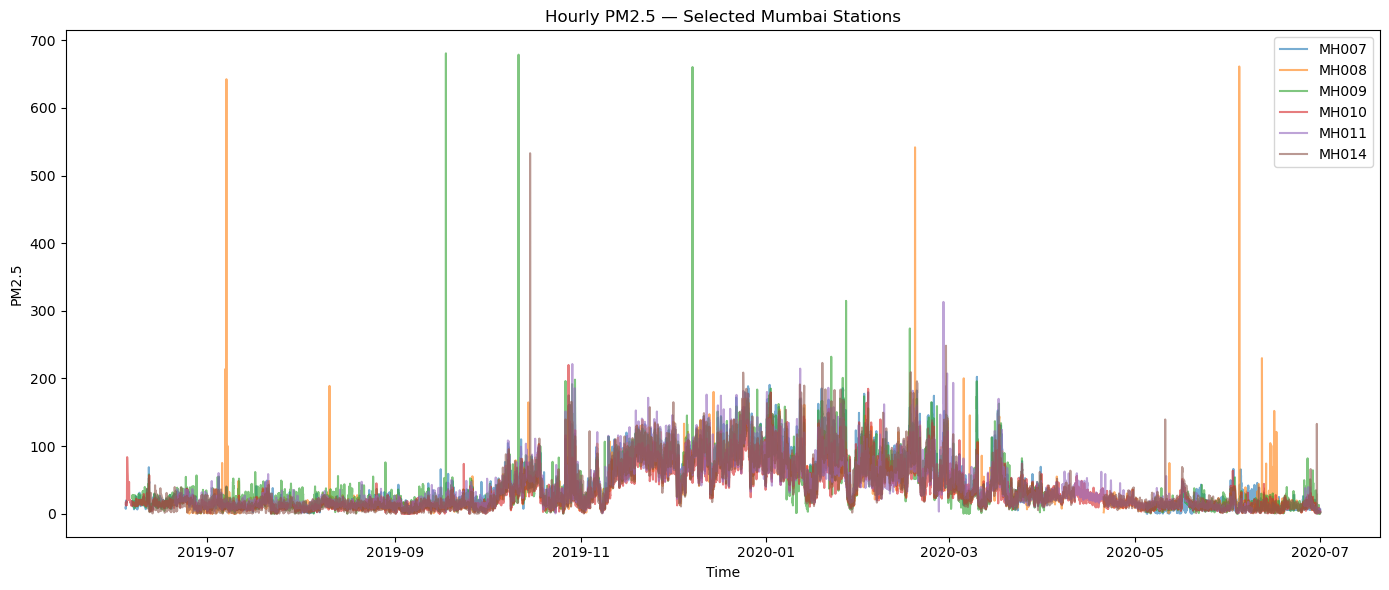

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for station_id, group in mumbai_clean.groupby("StationId"):
    plt.plot(
        group["Datetime"],
        group["PM2.5"],
        label=station_id,
        alpha=0.6
    )

plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.title("Hourly PM2.5 — Selected Mumbai Stations")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Look at observations around the largest PM2.5 values

extreme_times = (
    mumbai_clean
    .nlargest(10, "PM2.5")[["Datetime", "StationId", "PM2.5"]]
)

print(extreme_times)

                   Datetime StationId    PM2.5
1776041 2019-09-17 16:00:00     MH009  680.730
1776614 2019-10-11 13:00:00     MH009  678.760
1772928 2020-06-04 09:00:00     MH008  661.310
1777986 2019-12-07 17:00:00     MH009  660.500
1764940 2019-07-07 13:00:00     MH008  642.500
1770371 2020-02-18 20:00:00     MH008  541.750
1823300 2019-10-15 08:00:00     MH014  533.000
1772929 2020-06-04 10:00:00     MH008  509.350
1776613 2019-10-11 12:00:00     MH009  352.380
1772927 2020-06-04 08:00:00     MH008  342.655


In [31]:
for _, row in extreme_times.head(10).iterrows():

    station = row["StationId"]
    time = row["Datetime"]

    nearby = mumbai_clean[
        (mumbai_clean["StationId"] == station) &
        (
            mumbai_clean["Datetime"].between(
                time - pd.Timedelta(hours=3),
                time + pd.Timedelta(hours=3)
            )
        )
    ][["Datetime", "StationId", "PM2.5"]]

    print("\n" + "="*60)
    print(f"Station: {station}")
    print(f"Extreme time: {time}")
    print(nearby.to_string(index=False))


Station: MH009
Extreme time: 2019-09-17 16:00:00
           Datetime StationId  PM2.5
2019-09-17 13:00:00     MH009  16.16
2019-09-17 14:00:00     MH009   5.00
2019-09-17 15:00:00     MH009   5.00
2019-09-17 16:00:00     MH009 680.73
2019-09-17 17:00:00     MH009   7.39
2019-09-17 18:00:00     MH009  13.61
2019-09-17 19:00:00     MH009  21.81

Station: MH009
Extreme time: 2019-10-11 13:00:00
           Datetime StationId  PM2.5
2019-10-11 10:00:00     MH009  27.84
2019-10-11 11:00:00     MH009  26.00
2019-10-11 12:00:00     MH009 352.38
2019-10-11 13:00:00     MH009 678.76
2019-10-11 14:00:00     MH009  29.57
2019-10-11 15:00:00     MH009  51.59
2019-10-11 16:00:00     MH009  58.27

Station: MH008
Extreme time: 2020-06-04 09:00:00
           Datetime StationId   PM2.5
2020-06-04 06:00:00     MH008  17.100
2020-06-04 07:00:00     MH008  24.000
2020-06-04 08:00:00     MH008 342.655
2020-06-04 09:00:00     MH008 661.310
2020-06-04 10:00:00     MH008 509.350
2020-06-04 11:00:00     MH008 

In [32]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO2",
    "NO",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3"
]

for _, row in extreme_times.head(10).iterrows():

    station = row["StationId"]
    time = row["Datetime"]

    record = mumbai_clean[
        (mumbai_clean["StationId"] == station) &
        (mumbai_clean["Datetime"] == time)
    ]

    print("\n" + "="*60)
    print("Station:", station)
    print("Time:", time)

    print(record[pollutants].to_string(index=False))


Station: MH009
Time: 2019-09-17 16:00:00
 PM2.5  PM10   NO2    NO   NOx  NH3   CO  SO2   O3
680.73   NaN 29.73 31.37 61.11 3.65 0.29 6.31 7.66

Station: MH009
Time: 2019-10-11 13:00:00
 PM2.5  PM10   NO2   NO   NOx   NH3   CO  SO2   O3
678.76   NaN 31.03 3.74 34.77 18.04 0.32  NaN 6.43

Station: MH008
Time: 2020-06-04 09:00:00
 PM2.5  PM10  NO2   NO   NOx  NH3   CO  SO2    O3
661.31 967.1  6.3 4.64 10.95 3.81 0.32 0.08 30.87

Station: MH009
Time: 2019-12-07 17:00:00
 PM2.5  PM10  NO2  NO  NOx  NH3  CO  SO2     O3
 660.5   NaN  NaN NaN  NaN  NaN 0.3  NaN 105.35

Station: MH008
Time: 2019-07-07 13:00:00
 PM2.5   PM10  NO2  NO  NOx  NH3   CO  SO2  O3
 642.5 909.25  NaN NaN  NaN  NaN 0.14  NaN NaN

Station: MH008
Time: 2020-02-18 20:00:00
 PM2.5   PM10   NO2   NO   NOx   NH3   CO   SO2     O3
541.75 688.38 31.33 5.92 37.25 15.44 0.69 10.31 104.68

Station: MH014
Time: 2019-10-15 08:00:00
 PM2.5  PM10  NO2    NO   NOx   NH3   CO  SO2   O3
 533.0 596.0 4.49 49.98 54.48 52.07 1.21 9.98 7.35


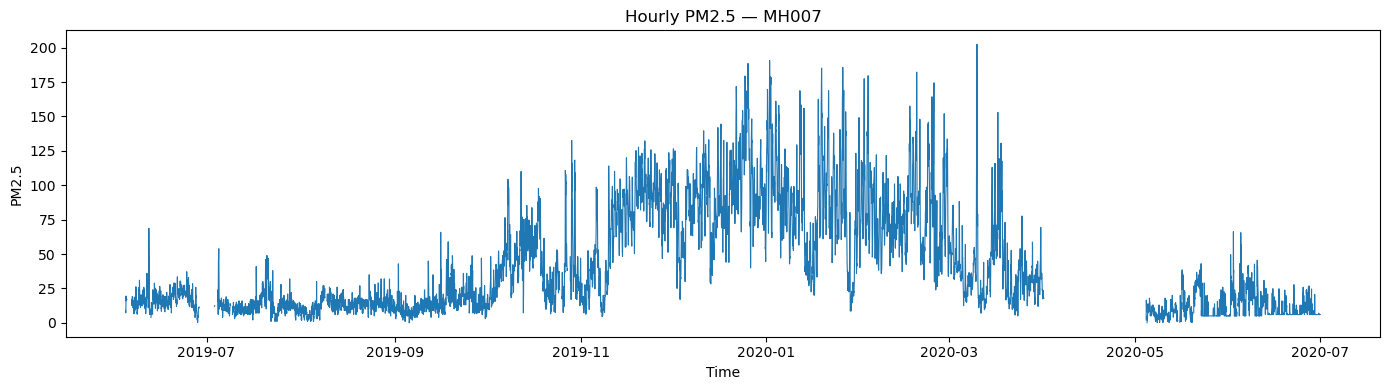

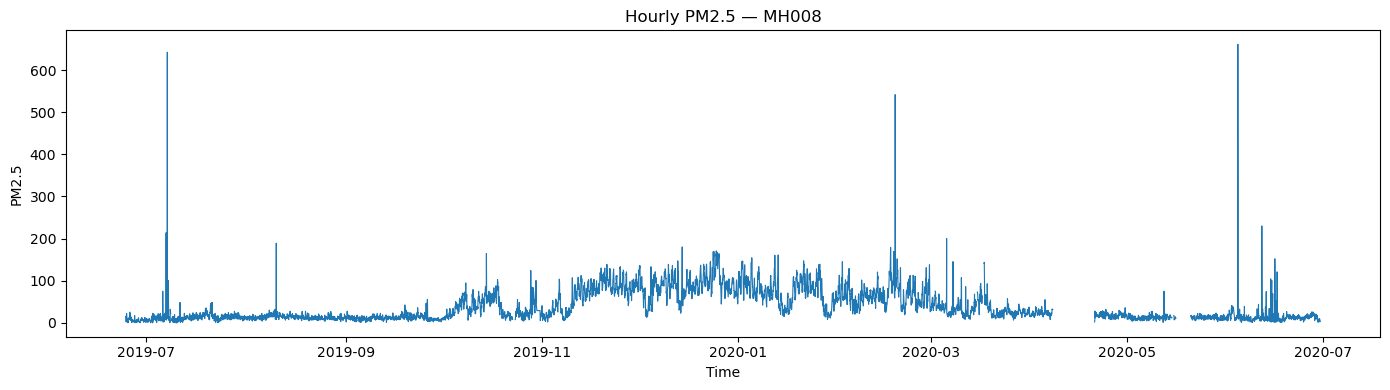

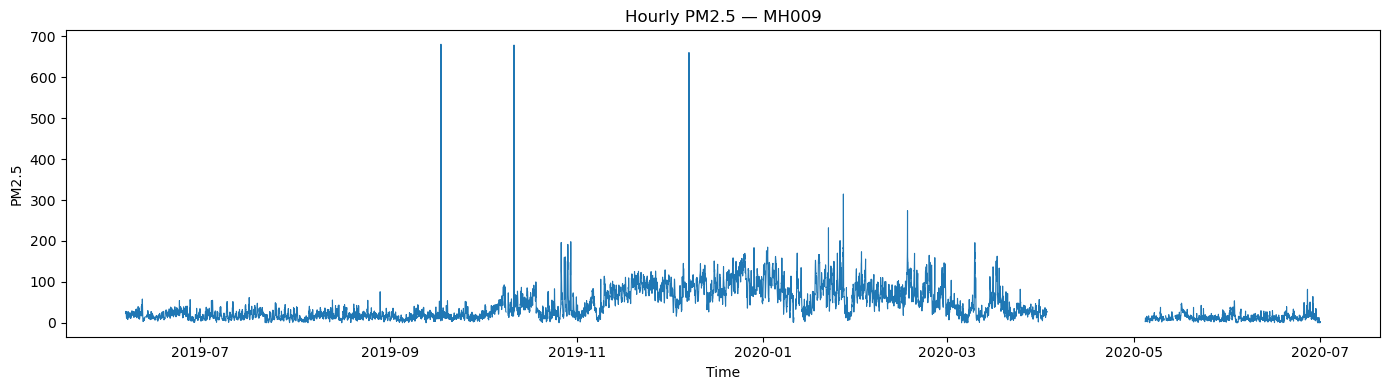

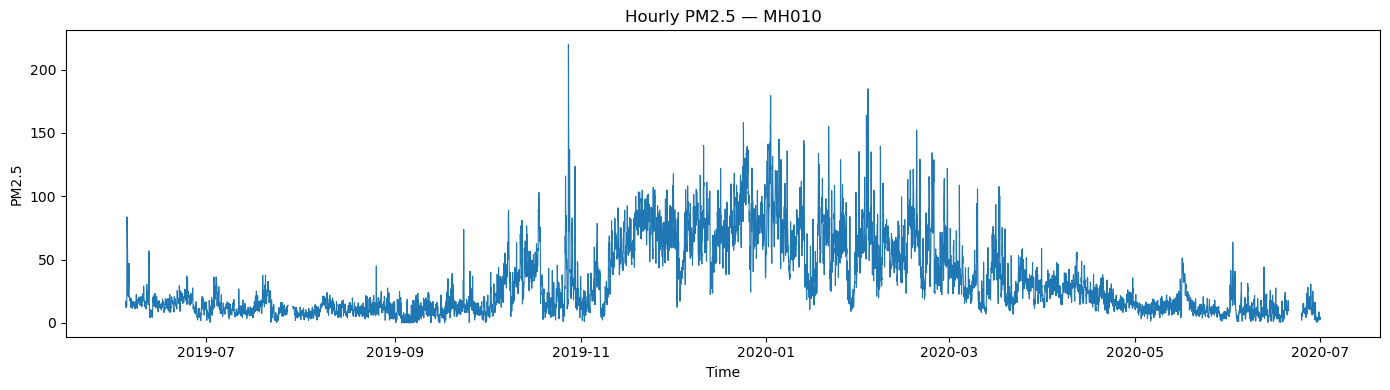

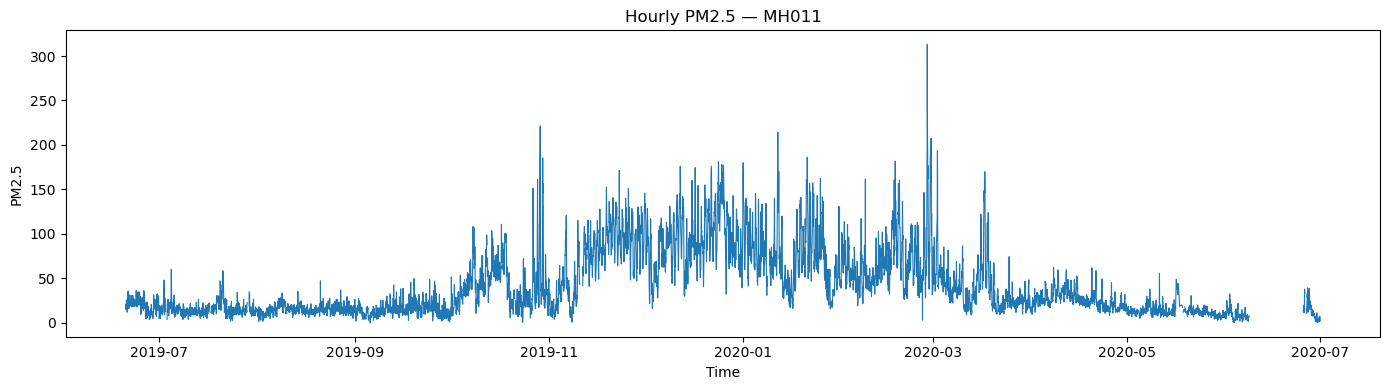

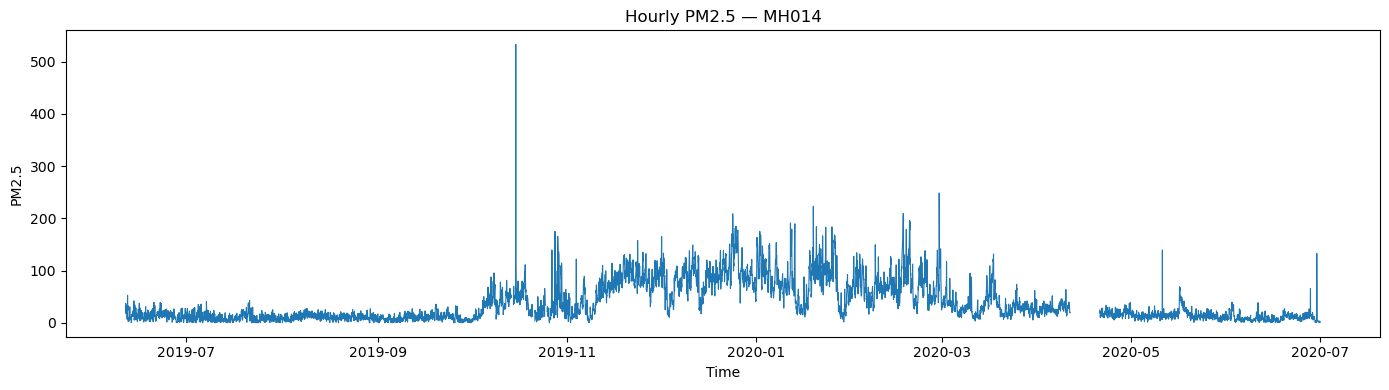

In [33]:
import matplotlib.pyplot as plt

for station_id, group in mumbai_clean.groupby("StationId"):

    plt.figure(figsize=(14, 4))

    plt.plot(
        group["Datetime"],
        group["PM2.5"],
        linewidth=0.8
    )

    plt.title(f"Hourly PM2.5 — {station_id}")
    plt.xlabel("Time")
    plt.ylabel("PM2.5")
    plt.tight_layout()
    plt.show()

In [34]:
for _, row in extreme_times.head(10).iterrows():
    station = row["StationId"]
    time = row["Datetime"]

    nearby = mumbai_clean[
        (mumbai_clean["StationId"] == station) &
        (
            mumbai_clean["Datetime"].between(
                time - pd.Timedelta(hours=3),
                time + pd.Timedelta(hours=3)
            )
        )
    ][["Datetime", "StationId", "PM2.5"]]

    print("\n" + "="*60)
    print(f"Station: {station}")
    print(f"Extreme time: {time}")
    print(nearby.to_string(index=False))


Station: MH009
Extreme time: 2019-09-17 16:00:00
           Datetime StationId  PM2.5
2019-09-17 13:00:00     MH009  16.16
2019-09-17 14:00:00     MH009   5.00
2019-09-17 15:00:00     MH009   5.00
2019-09-17 16:00:00     MH009 680.73
2019-09-17 17:00:00     MH009   7.39
2019-09-17 18:00:00     MH009  13.61
2019-09-17 19:00:00     MH009  21.81

Station: MH009
Extreme time: 2019-10-11 13:00:00
           Datetime StationId  PM2.5
2019-10-11 10:00:00     MH009  27.84
2019-10-11 11:00:00     MH009  26.00
2019-10-11 12:00:00     MH009 352.38
2019-10-11 13:00:00     MH009 678.76
2019-10-11 14:00:00     MH009  29.57
2019-10-11 15:00:00     MH009  51.59
2019-10-11 16:00:00     MH009  58.27

Station: MH008
Extreme time: 2020-06-04 09:00:00
           Datetime StationId   PM2.5
2020-06-04 06:00:00     MH008  17.100
2020-06-04 07:00:00     MH008  24.000
2020-06-04 08:00:00     MH008 342.655
2020-06-04 09:00:00     MH008 661.310
2020-06-04 10:00:00     MH008 509.350
2020-06-04 11:00:00     MH008 

In [35]:
pollutants = [
    "PM2.5", "PM10", "NO2", "NO",
    "NOx", "NH3", "CO", "SO2", "O3"
]

for _, row in extreme_times.head(10).iterrows():

    station = row["StationId"]
    time = row["Datetime"]

    record = mumbai_clean[
        (mumbai_clean["StationId"] == station) &
        (mumbai_clean["Datetime"] == time)
    ]

    print("\n" + "="*60)
    print("Station:", station)
    print("Time:", time)
    print(record[pollutants].to_string(index=False))


Station: MH009
Time: 2019-09-17 16:00:00
 PM2.5  PM10   NO2    NO   NOx  NH3   CO  SO2   O3
680.73   NaN 29.73 31.37 61.11 3.65 0.29 6.31 7.66

Station: MH009
Time: 2019-10-11 13:00:00
 PM2.5  PM10   NO2   NO   NOx   NH3   CO  SO2   O3
678.76   NaN 31.03 3.74 34.77 18.04 0.32  NaN 6.43

Station: MH008
Time: 2020-06-04 09:00:00
 PM2.5  PM10  NO2   NO   NOx  NH3   CO  SO2    O3
661.31 967.1  6.3 4.64 10.95 3.81 0.32 0.08 30.87

Station: MH009
Time: 2019-12-07 17:00:00
 PM2.5  PM10  NO2  NO  NOx  NH3  CO  SO2     O3
 660.5   NaN  NaN NaN  NaN  NaN 0.3  NaN 105.35

Station: MH008
Time: 2019-07-07 13:00:00
 PM2.5   PM10  NO2  NO  NOx  NH3   CO  SO2  O3
 642.5 909.25  NaN NaN  NaN  NaN 0.14  NaN NaN

Station: MH008
Time: 2020-02-18 20:00:00
 PM2.5   PM10   NO2   NO   NOx   NH3   CO   SO2     O3
541.75 688.38 31.33 5.92 37.25 15.44 0.69 10.31 104.68

Station: MH014
Time: 2019-10-15 08:00:00
 PM2.5  PM10  NO2    NO   NOx   NH3   CO  SO2   O3
 533.0 596.0 4.49 49.98 54.48 52.07 1.21 9.98 7.35


In [36]:
# Create a copy
mumbai_clean = mumbai_clean.copy()

# Initialize outlier flag
mumbai_clean["PM2.5_outlier_flag"] = 0

# Suspicious isolated events identified from our investigation
suspicious_events = [
    ("MH009", "2019-09-17 16:00:00"),
    ("MH009", "2019-10-11 12:00:00"),
    ("MH009", "2019-10-11 13:00:00"),
    ("MH009", "2019-12-07 17:00:00"),
    ("MH008", "2019-07-07 13:00:00"),
    ("MH014", "2019-10-15 08:00:00"),
]

for station, timestamp in suspicious_events:
    mask = (
        (mumbai_clean["StationId"] == station) &
        (mumbai_clean["Datetime"] == pd.Timestamp(timestamp))
    )

    mumbai_clean.loc[mask, "PM2.5_outlier_flag"] = 1

print(
    mumbai_clean["PM2.5_outlier_flag"].value_counts()
)

0    55440
1        6
Name: PM2.5_outlier_flag, dtype: int64


In [38]:
print(mumbai_clean.columns.tolist())

['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'PM2.5_outlier_flag']


In [39]:
print(mumbai_clean["StationId"].unique())

['MH007' 'MH008' 'MH009' 'MH010' 'MH011' 'MH014']


In [40]:
print(mumbai_clean.groupby("StationId").size())

StationId
MH007    9423
MH008    8941
MH009    9370
MH010    9422
MH011    9035
MH014    9255
dtype: int64


In [41]:
mumbai_clean.to_csv(
    "mumbai_pollution_clean.csv",
    index=False
)

In [42]:
import os

print(
    "File exists:",
    os.path.exists("mumbai_pollution_clean.csv")
)

print(
    "Rows:",
    len(mumbai_clean)
)

File exists: True
Rows: 55446


In [43]:
import os

print(os.listdir())

['.gitkeep', '01_mumbai_data_analysis.ipynb', 'mumbai_pollution_clean.csv']


In [44]:
import requests

print("requests is working")

requests is working


In [45]:
import os

print(os.listdir())

['.gitkeep', '01_mumbai_data_analysis.ipynb', 'mumbai_pollution_clean.csv']


In [46]:
import pandas as pd

pollution = pd.read_csv(
    "mumbai_pollution_clean.csv",
    parse_dates=["Datetime"]
)

print(pollution.shape)
print(pollution["Datetime"].min())
print(pollution["Datetime"].max())
print(pollution.head())

(55446, 17)
2019-06-04 10:00:00
2020-07-01 00:00:00
  StationId            Datetime  PM2.5   PM10     NO    NO2    NOx    NH3  \
0     MH007 2019-06-04 10:00:00   9.00  48.49  43.02  12.84  55.85  14.66   
1     MH007 2019-06-04 11:00:00   7.27  73.58  36.62  15.18  51.80  13.67   
2     MH007 2019-06-04 12:00:00   9.60  55.07  42.89  13.66  56.56   8.73   
3     MH007 2019-06-04 13:00:00  19.50  58.16  26.21  13.66  39.87   6.52   
4     MH007 2019-06-04 14:00:00  16.67  64.89  35.01  14.36  49.36   7.19   

     CO   SO2     O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  \
0  0.47  6.47   6.29     9.44      NaN     NaN  NaN        NaN   
1  0.35  5.50   9.09     8.65      NaN     NaN  NaN        NaN   
2  0.26  0.85  11.95     7.11      NaN     NaN  NaN        NaN   
3  0.20  3.01  15.03     6.02      NaN     NaN  NaN        NaN   
4  0.25  3.60  10.23     5.00      NaN     NaN  NaN        NaN   

   PM2.5_outlier_flag  
0                   0  
1                   0  
2               

In [47]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 19.0760,
    "longitude": 72.8777,
    "start_date": "2019-06-04",
    "end_date": "2020-07-01",
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "surface_pressure",
        "wind_speed_10m",
        "wind_direction_10m",
        "cloud_cover"
    ],
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [48]:
weather_data = response.json()

print(weather_data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [49]:
weather = pd.DataFrame(weather_data["hourly"])

print("Shape:", weather.shape)
print(weather.head())
print(weather.columns.tolist())

Shape: (9456, 8)
               time  temperature_2m  relative_humidity_2m  precipitation  \
0  2019-06-04T00:00            28.9                    78            0.0   
1  2019-06-04T01:00            28.7                    80            0.0   
2  2019-06-04T02:00            28.6                    80            0.0   
3  2019-06-04T03:00            28.4                    81            0.0   
4  2019-06-04T04:00            28.2                    82            0.0   

   surface_pressure  wind_speed_10m  wind_direction_10m  cloud_cover  
0            1006.4            11.2                 249           22  
1            1005.6            10.2                 260           29  
2            1005.2            10.1                 270           16  
3            1004.9             9.4                 277            9  
4            1004.8             9.4                 277           33  
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_

In [50]:
weather = weather.rename(columns={
    "time": "Datetime",
    "temperature_2m": "Temperature",
    "relative_humidity_2m": "Humidity",
    "precipitation": "Rainfall",
    "surface_pressure": "Pressure",
    "wind_speed_10m": "WindSpeed",
    "wind_direction_10m": "WindDirection",
    "cloud_cover": "CloudCover"
})

weather["Datetime"] = pd.to_datetime(weather["Datetime"])

print(weather.head())
print(weather.shape)

             Datetime  Temperature  Humidity  Rainfall  Pressure  WindSpeed  \
0 2019-06-04 00:00:00         28.9        78       0.0    1006.4       11.2   
1 2019-06-04 01:00:00         28.7        80       0.0    1005.6       10.2   
2 2019-06-04 02:00:00         28.6        80       0.0    1005.2       10.1   
3 2019-06-04 03:00:00         28.4        81       0.0    1004.9        9.4   
4 2019-06-04 04:00:00         28.2        82       0.0    1004.8        9.4   

   WindDirection  CloudCover  
0            249          22  
1            260          29  
2            270          16  
3            277           9  
4            277          33  
(9456, 8)


In [51]:
print("Weather start:", weather["Datetime"].min())
print("Weather end:", weather["Datetime"].max())

print("\nWeather duplicate timestamps:",
      weather["Datetime"].duplicated().sum())

print("\nWeather missing values:")
print(weather.isna().sum())

Weather start: 2019-06-04 00:00:00
Weather end: 2020-07-01 23:00:00

Weather duplicate timestamps: 0

Weather missing values:
Datetime         0
Temperature      0
Humidity         0
Rainfall         0
Pressure         0
WindSpeed        0
WindDirection    0
CloudCover       0
dtype: int64


In [52]:
pollution_times = set(pollution["Datetime"])
weather_times = set(weather["Datetime"])

common_times = pollution_times.intersection(weather_times)

print("Pollution unique timestamps:", len(pollution_times))
print("Weather timestamps:", len(weather_times))
print("Common timestamps:", len(common_times))

Pollution unique timestamps: 9423
Weather timestamps: 9456
Common timestamps: 9423


In [53]:
# Make sure both datasets are sorted
pollution = pollution.sort_values(["StationId", "Datetime"])
weather = weather.sort_values("Datetime")

# Merge weather onto every station observation
combined = pollution.merge(
    weather,
    on="Datetime",
    how="left"
)

print("Combined shape:", combined.shape)

print("\nMissing weather values:")
print(combined[
    ["Temperature", "Humidity", "Rainfall",
     "Pressure", "WindSpeed", "WindDirection", "CloudCover"]
].isna().sum())

Combined shape: (55446, 24)

Missing weather values:
Temperature      0
Humidity         0
Rainfall         0
Pressure         0
WindSpeed        0
WindDirection    0
CloudCover       0
dtype: int64


In [54]:
print(combined.head())
print("\nColumns:")
print(combined.columns.tolist())

  StationId            Datetime  PM2.5   PM10     NO    NO2    NOx    NH3  \
0     MH007 2019-06-04 10:00:00   9.00  48.49  43.02  12.84  55.85  14.66   
1     MH007 2019-06-04 11:00:00   7.27  73.58  36.62  15.18  51.80  13.67   
2     MH007 2019-06-04 12:00:00   9.60  55.07  42.89  13.66  56.56   8.73   
3     MH007 2019-06-04 13:00:00  19.50  58.16  26.21  13.66  39.87   6.52   
4     MH007 2019-06-04 14:00:00  16.67  64.89  35.01  14.36  49.36   7.19   

     CO   SO2  ...  AQI  AQI_Bucket  PM2.5_outlier_flag  Temperature  \
0  0.47  6.47  ...  NaN         NaN                   0         31.3   
1  0.35  5.50  ...  NaN         NaN                   0         32.1   
2  0.26  0.85  ...  NaN         NaN                   0         32.5   
3  0.20  3.01  ...  NaN         NaN                   0         32.3   
4  0.25  3.60  ...  NaN         NaN                   0         32.4   

   Humidity Rainfall  Pressure  WindSpeed  WindDirection  CloudCover  
0        66      0.2    1007.9   

In [55]:
combined.to_csv(
    "mumbai_pollution_weather.csv",
    index=False
)

print("Saved successfully!")
print("Rows:", len(combined))

Saved successfully!
Rows: 55446


In [56]:
import pandas as pd

df = pd.read_csv(
    "mumbai_pollution_weather.csv",
    parse_dates=["Datetime"]
)

print("Shape:", df.shape)
print("\nDate range:")
print(df["Datetime"].min())
print(df["Datetime"].max())

print("\nStations:")
print(df["StationId"].value_counts())

Shape: (55446, 24)

Date range:
2019-06-04 10:00:00
2020-07-01 00:00:00

Stations:
MH007    9423
MH010    9422
MH009    9370
MH014    9255
MH011    9035
MH008    8941
Name: StationId, dtype: int64


In [57]:
print(df[
    [
        "Datetime",
        "StationId",
        "PM2.5",
        "Temperature",
        "Humidity",
        "Rainfall",
        "Pressure",
        "WindSpeed",
        "WindDirection",
        "CloudCover"
    ]
].head(10))

             Datetime StationId  PM2.5  Temperature  Humidity  Rainfall  \
0 2019-06-04 10:00:00     MH007   9.00         31.3        66       0.2   
1 2019-06-04 11:00:00     MH007   7.27         32.1        63       0.1   
2 2019-06-04 12:00:00     MH007   9.60         32.5        61       0.0   
3 2019-06-04 13:00:00     MH007  19.50         32.3        61       0.0   
4 2019-06-04 14:00:00     MH007  16.67         32.4        58       0.0   
5 2019-06-04 15:00:00     MH007  16.00         32.3        56       0.0   
6 2019-06-04 16:00:00     MH007  16.87         31.7        57       0.0   
7 2019-06-04 17:00:00     MH007  17.00         30.8        66       0.0   
8 2019-06-04 18:00:00     MH007  17.00         30.1        70       0.0   
9 2019-06-04 19:00:00     MH007  17.00         29.5        70       0.0   

   Pressure  WindSpeed  WindDirection  CloudCover  
0    1007.9       17.7            264          71  
1    1007.5       18.4            272          71  
2    1006.9       

In [58]:
print(df[
    [
        "PM2.5",
        "PM10",
        "NO2",
        "CO",
        "Temperature",
        "Humidity",
        "Rainfall",
        "Pressure",
        "WindSpeed"
    ]
].describe().T)

               count         mean        std     min      25%      50%  \
PM2.5        52051.0    38.472298  36.167232    0.02    12.00    22.86   
PM10         51494.0    95.374923  74.938565    0.20    42.00    71.81   
NO2          51747.0    26.425195  27.505414    0.01     6.60    17.09   
CO           52654.0     0.547950   0.629694    0.00     0.23     0.39   
Temperature  55446.0    26.719161   2.980803   15.30    25.50    26.70   
Humidity     55446.0    77.951719  15.747890   15.00    68.00    83.00   
Rainfall     55446.0     0.327636   1.235751    0.00     0.00     0.00   
Pressure     55446.0  1008.075490   3.861403  987.20  1005.10  1008.50   
WindSpeed    55446.0    12.273215   6.516421    0.00     7.00    11.30   

                  75%      max  
PM2.5          59.615   680.73  
PM10          131.780   985.00  
NO2            35.910   240.71  
CO              0.700     9.96  
Temperature    28.300    36.70  
Humidity       91.000   100.00  
Rainfall        0.200    40.

In [59]:
station_pm25 = (
    df.groupby("StationId")["PM2.5"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

print(station_pm25)

           count   mean  median    std   min     max
StationId                                           
MH007       8328  42.06   24.76  38.20  0.04  202.45
MH008       8424  38.34   21.14  37.27  0.03  661.31
MH009       8530  40.54   25.13  38.31  0.02  680.73
MH010       9284  32.37   20.08  28.72  0.03  219.95
MH011       8513  41.46   26.38  36.17  0.17  313.20
MH014       8972  36.77   20.06  37.09  0.08  533.00


In [60]:
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month

print(
    df[
        ["Datetime", "Hour", "DayOfWeek", "Month"]
    ].head()
)

             Datetime  Hour  DayOfWeek  Month
0 2019-06-04 10:00:00    10          1      6
1 2019-06-04 11:00:00    11          1      6
2 2019-06-04 12:00:00    12          1      6
3 2019-06-04 13:00:00    13          1      6
4 2019-06-04 14:00:00    14          1      6


In [61]:
hourly_pm25 = (
    df.groupby("Hour")["PM2.5"]
      .mean()
)

print(hourly_pm25)

Hour
0     41.207819
1     42.045803
2     41.557587
3     41.216181
4     40.216808
5     39.594053
6     38.962858
7     39.900331
8     42.658740
9     45.469721
10    45.018353
11    42.299534
12    39.583422
13    37.062690
14    33.847183
15    32.303004
16    32.916026
17    32.943444
18    32.602473
19    33.012721
20    34.690986
21    36.467886
22    38.183282
23    39.976072
Name: PM2.5, dtype: float64


In [62]:
monthly_pm25 = (
    df.groupby("Month")["PM2.5"]
      .mean()
)

print(monthly_pm25)

Month
1     75.618076
2     71.290005
3     35.039013
4     23.516075
5     12.718482
6     14.094806
7     13.687576
8     13.259108
9     13.013504
10    38.814771
11    65.873447
12    87.430641
Name: PM2.5, dtype: float64


In [63]:
corr_cols = [
    "PM2.5",
    "PM10",
    "NO2",
    "NO",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Temperature",
    "Humidity",
    "Rainfall",
    "Pressure",
    "WindSpeed",
    "CloudCover"
]

correlation = df[corr_cols].corr()["PM2.5"].sort_values(
    ascending=False
)

print(correlation)

PM2.5          1.000000
PM10           0.832865
Pressure       0.605400
NO2            0.586470
NOx            0.516782
CO             0.474446
NO             0.284072
O3             0.254241
NH3            0.224706
SO2            0.095580
Rainfall      -0.191065
Temperature   -0.279184
WindSpeed     -0.317584
CloudCover    -0.389369
Humidity      -0.392379
Name: PM2.5, dtype: float64


In [64]:
df.to_csv(
    "mumbai_final_eda.csv",
    index=False
)

print("Saved:", len(df), "rows")

Saved: 55446 rows


In [65]:
print(station_pm25)

           count   mean  median    std   min     max
StationId                                           
MH007       8328  42.06   24.76  38.20  0.04  202.45
MH008       8424  38.34   21.14  37.27  0.03  661.31
MH009       8530  40.54   25.13  38.31  0.02  680.73
MH010       9284  32.37   20.08  28.72  0.03  219.95
MH011       8513  41.46   26.38  36.17  0.17  313.20
MH014       8972  36.77   20.06  37.09  0.08  533.00


In [66]:
print(hourly_pm25)

Hour
0     41.207819
1     42.045803
2     41.557587
3     41.216181
4     40.216808
5     39.594053
6     38.962858
7     39.900331
8     42.658740
9     45.469721
10    45.018353
11    42.299534
12    39.583422
13    37.062690
14    33.847183
15    32.303004
16    32.916026
17    32.943444
18    32.602473
19    33.012721
20    34.690986
21    36.467886
22    38.183282
23    39.976072
Name: PM2.5, dtype: float64


In [67]:
print(correlation)

PM2.5          1.000000
PM10           0.832865
Pressure       0.605400
NO2            0.586470
NOx            0.516782
CO             0.474446
NO             0.284072
O3             0.254241
NH3            0.224706
SO2            0.095580
Rainfall      -0.191065
Temperature   -0.279184
WindSpeed     -0.317584
CloudCover    -0.389369
Humidity      -0.392379
Name: PM2.5, dtype: float64


In [68]:
missing = df.isna().sum().sort_values(ascending=False)

print(missing[missing > 0])

Xylene        55446
Toluene       55446
SO2            5047
Benzene        4450
PM10           3952
NO2            3699
O3             3405
PM2.5          3395
CO             2792
NH3            2689
NO             2464
NOx            2350
AQI            1948
AQI_Bucket     1948
dtype: int64


In [69]:
print("PM2.5 missing:", df["PM2.5"].isna().sum())
print("PM2.5 rows:", len(df))

PM2.5 missing: 3395
PM2.5 rows: 55446


In [70]:
print(
    df.groupby("StationId")["PM2.5"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

           count   mean  median    std   min     max
StationId                                           
MH007       8328  42.06   24.76  38.20  0.04  202.45
MH008       8424  38.34   21.14  37.27  0.03  661.31
MH009       8530  40.54   25.13  38.31  0.02  680.73
MH010       9284  32.37   20.08  28.72  0.03  219.95
MH011       8513  41.46   26.38  36.17  0.17  313.20
MH014       8972  36.77   20.06  37.09  0.08  533.00


In [73]:
df_check = df.sort_values(["StationId", "Datetime"]).copy()

df_check["pm25_missing"] = df_check["PM2.5"].isna()

# Identify consecutive missing periods separately for each station
df_check["gap_group"] = (
    df_check.groupby("StationId")["pm25_missing"]
    .transform(lambda x: x.ne(x.shift()).cumsum())
)

missing_gaps = (
    df_check[df_check["pm25_missing"]]
    .groupby(["StationId", "gap_group"])
    .agg(
        start=("Datetime", "min"),
        end=("Datetime", "max"),
        missing_hours=("Datetime", "count")
    )
    .reset_index()
)

print("Total missing PM2.5:", df["PM2.5"].isna().sum())

print("\nGap statistics:")
print(missing_gaps["missing_hours"].describe())

print("\nLargest 20 gaps:")
print(
    missing_gaps
    .sort_values("missing_hours", ascending=False)
    .head(20)
)

Total missing PM2.5: 3395

Gap statistics:
count     83.000000
mean      40.903614
std      133.341906
min        1.000000
25%        2.000000
50%        5.000000
75%       14.500000
max      806.000000
Name: missing_hours, dtype: float64

Largest 20 gaps:
   StationId  gap_group               start                 end  missing_hours
9      MH007         20 2020-04-01 05:00:00 2020-05-04 18:00:00            806
48     MH009         16 2020-04-02 20:00:00 2020-05-04 18:00:00            767
70     MH011         28 2020-06-08 15:00:00 2020-06-25 14:00:00            408
32     MH008         21 2020-04-07 21:00:00 2020-04-20 19:00:00            311
79     MH014         16 2020-04-11 08:00:00 2020-04-20 18:00:00            227
2      MH007          6 2019-06-28 16:00:00 2019-07-03 13:00:00            118
38     MH008         33 2020-05-16 04:00:00 2020-05-20 17:00:00            110
56     MH010          8 2020-06-20 17:00:00 2020-06-24 18:00:00             98
0      MH007          2 2019-06-

In [74]:
print("\nNumber of gaps by length:")

print(
    missing_gaps["missing_hours"]
    .value_counts()
    .sort_index()
)


Number of gaps by length:
1      19
2      10
3       7
4       3
5       3
6       5
7       2
9       1
10      3
11      2
12      2
13      4
14      1
15      5
16      1
18      1
20      2
21      1
24      1
37      2
98      1
110     1
118     1
227     1
311     1
408     1
767     1
806     1
Name: missing_hours, dtype: int64


In [75]:
df_final = df.copy()

df_final = df_final.sort_values(
    ["StationId", "Datetime"]
).reset_index(drop=True)

In [76]:
# Number of consecutive missing PM2.5 values
df_final["PM2.5_missing"] = df_final["PM2.5"].isna()

df_final["missing_group"] = (
    df_final.groupby("StationId")["PM2.5_missing"]
    .transform(lambda x: x.ne(x.shift()).cumsum())
)

# Calculate gap length
gap_lengths = (
    df_final.groupby(["StationId", "missing_group"])["PM2.5_missing"]
    .transform("sum")
)

df_final["pm25_gap_length"] = gap_lengths

In [77]:
short_gap_mask = (
    df_final["PM2.5"].isna() &
    (df_final["pm25_gap_length"] <= 6)
)

print("Values eligible for interpolation:",
      short_gap_mask.sum())

Values eligible for interpolation: 117


In [78]:
df_final.loc[short_gap_mask, "PM2.5"] = (
    df_final.groupby("StationId")["PM2.5"]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit=6,
            limit_area="inside"
        )
    )
)

In [79]:
print("Original missing:", df["PM2.5"].isna().sum())
print("Remaining missing:", df_final["PM2.5"].isna().sum())
print(
    "Filled:",
    df["PM2.5"].isna().sum() -
    df_final["PM2.5"].isna().sum()
)

Original missing: 3395
Remaining missing: 3280
Filled: 115


In [80]:
output_path = "mumbai_forecasting_ready.csv"

df_final.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(df_final))

Saved: mumbai_forecasting_ready.csv
Rows: 55446


In [81]:
print(df_final.columns.tolist())

['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'PM2.5_outlier_flag', 'Temperature', 'Humidity', 'Rainfall', 'Pressure', 'WindSpeed', 'WindDirection', 'CloudCover', 'Hour', 'DayOfWeek', 'Month', 'PM2.5_missing', 'missing_group', 'pm25_gap_length']


In [82]:
print(df_final.head())

  StationId            Datetime  PM2.5   PM10     NO    NO2    NOx    NH3  \
0     MH007 2019-06-04 10:00:00   9.00  48.49  43.02  12.84  55.85  14.66   
1     MH007 2019-06-04 11:00:00   7.27  73.58  36.62  15.18  51.80  13.67   
2     MH007 2019-06-04 12:00:00   9.60  55.07  42.89  13.66  56.56   8.73   
3     MH007 2019-06-04 13:00:00  19.50  58.16  26.21  13.66  39.87   6.52   
4     MH007 2019-06-04 14:00:00  16.67  64.89  35.01  14.36  49.36   7.19   

     CO   SO2  ...  Pressure  WindSpeed  WindDirection  CloudCover  Hour  \
0  0.47  6.47  ...    1007.9       17.7            264          71    10   
1  0.35  5.50  ...    1007.5       18.4            272          71    11   
2  0.26  0.85  ...    1006.9       18.4            281          60    12   
3  0.20  3.01  ...    1006.1       17.5            284          14    13   
4  0.25  3.60  ...    1005.4       18.1            283           2    14   

  DayOfWeek  Month  PM2.5_missing  missing_group  pm25_gap_length  
0         1 

In [83]:
model_features = [
    "StationId",
    "Datetime",

    # Pollution
    "PM2.5",
    "PM10",
    "NO2",
    "NOx",
    "CO",
    "O3",
    "NH3",
    "SO2",

    # Weather
    "Temperature",
    "Humidity",
    "Rainfall",
    "Pressure",
    "WindSpeed",
    "WindDirection",
    "CloudCover",

    # Time
    "Hour",
    "DayOfWeek",
    "Month"
]

model_df = df_final[model_features].copy()

print("Shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

Shape: (55446, 20)

Columns:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO2', 'NOx', 'CO', 'O3', 'NH3', 'SO2', 'Temperature', 'Humidity', 'Rainfall', 'Pressure', 'WindSpeed', 'WindDirection', 'CloudCover', 'Hour', 'DayOfWeek', 'Month']


In [84]:
print(model_df.isna().sum().sort_values(ascending=False))

SO2              5047
PM10             3952
NO2              3699
O3               3405
PM2.5            3280
CO               2792
NH3              2689
NOx              2350
StationId           0
WindSpeed           0
DayOfWeek           0
Hour                0
CloudCover          0
WindDirection       0
Temperature         0
Pressure            0
Rainfall            0
Humidity            0
Datetime            0
Month               0
dtype: int64


In [85]:
for station in model_df["StationId"].unique():

    station_data = model_df[
        model_df["StationId"] == station
    ].sort_values("Datetime")

    time_diff = station_data["Datetime"].diff().dropna()

    print(f"\nStation: {station}")
    print(time_diff.value_counts().head())


Station: MH007
0 days 01:00:00    9422
Name: Datetime, dtype: int64

Station: MH008
0 days 01:00:00    8940
Name: Datetime, dtype: int64

Station: MH009
0 days 01:00:00    9369
Name: Datetime, dtype: int64

Station: MH010
0 days 01:00:00    9421
Name: Datetime, dtype: int64

Station: MH011
0 days 01:00:00    9034
Name: Datetime, dtype: int64

Station: MH014
0 days 01:00:00    9254
Name: Datetime, dtype: int64


In [86]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO2",
    "NOx",
    "CO",
    "O3",
    "NH3",
    "SO2"
]

for pollutant in pollutants:

    print("\n" + "="*50)
    print("POLLUTANT:", pollutant)
    print("="*50)

    for station in model_df["StationId"].unique():

        station_data = (
            model_df[
                model_df["StationId"] == station
            ]
            .sort_values("Datetime")
            .copy()
        )

        missing = station_data[pollutant].isna()

        # Create groups of consecutive missing values
        groups = (
            missing.ne(missing.shift()).cumsum()
        )

        gap_lengths = (
            missing.groupby(groups)
            .sum()
        )

        gap_lengths = gap_lengths[
            gap_lengths > 0
        ]

        print(
            station,
            "missing:",
            missing.sum(),
            "| gaps:",
            len(gap_lengths),
            "| largest:",
            gap_lengths.max() if len(gap_lengths) else 0
        )


POLLUTANT: PM2.5
MH007 missing: 1060 | gaps: 9 | largest: 806
MH008 missing: 490 | gaps: 7 | largest: 311
MH009 missing: 833 | gaps: 7 | largest: 767
MH010 missing: 135 | gaps: 2 | largest: 98
MH011 missing: 493 | gaps: 8 | largest: 408
MH014 missing: 269 | gaps: 4 | largest: 227

POLLUTANT: PM10
MH007 missing: 868 | gaps: 72 | largest: 179
MH008 missing: 713 | gaps: 138 | largest: 316
MH009 missing: 354 | gaps: 100 | largest: 43
MH010 missing: 991 | gaps: 203 | largest: 103
MH011 missing: 600 | gaps: 116 | largest: 38
MH014 missing: 426 | gaps: 78 | largest: 207

POLLUTANT: NO2
MH007 missing: 1180 | gaps: 182 | largest: 148
MH008 missing: 1163 | gaps: 140 | largest: 316
MH009 missing: 487 | gaps: 120 | largest: 23
MH010 missing: 345 | gaps: 72 | largest: 101
MH011 missing: 372 | gaps: 84 | largest: 84
MH014 missing: 152 | gaps: 45 | largest: 17

POLLUTANT: NOx
MH007 missing: 534 | gaps: 73 | largest: 148
MH008 missing: 937 | gaps: 110 | largest: 316
MH009 missing: 284 | gaps: 85 | la

In [87]:
final_features = [
    "StationId",
    "Datetime",

    # Target + pollution
    "PM2.5",
    "PM10",
    "NO2",
    "NOx",
    "CO",
    "O3",

    # Weather
    "Temperature",
    "Humidity",
    "Rainfall",
    "Pressure",
    "WindSpeed",
    "WindDirection",
    "CloudCover",

    # Time
    "Hour",
    "DayOfWeek",
    "Month"
]

forecast_df = df_final[final_features].copy()

print("Shape:", forecast_df.shape)
print(forecast_df.columns.tolist())

Shape: (55446, 18)
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO2', 'NOx', 'CO', 'O3', 'Temperature', 'Humidity', 'Rainfall', 'Pressure', 'WindSpeed', 'WindDirection', 'CloudCover', 'Hour', 'DayOfWeek', 'Month']


In [88]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO2",
    "NOx",
    "CO",
    "O3"
]

for pollutant in pollutants:

    for station in forecast_df["StationId"].unique():

        mask_station = (
            forecast_df["StationId"] == station
        )

        station_values = (
            forecast_df.loc[mask_station, pollutant]
            .copy()
        )

        # Interpolate only short internal gaps
        interpolated = station_values.interpolate(
            method="linear",
            limit=6,
            limit_area="inside"
        )

        forecast_df.loc[
            mask_station, pollutant
        ] = interpolated

In [89]:
print(
    forecast_df[
        pollutants
    ].isna().sum().sort_values(
        ascending=False
    )
)

PM2.5    3070
PM10     2188
O3       1959
NO2      1864
CO       1439
NOx      1299
dtype: int64


In [90]:
print("Overall:")
print(forecast_df["Datetime"].min())
print(forecast_df["Datetime"].max())

print("\nPer station:")

for station in forecast_df["StationId"].unique():
    data = forecast_df[
        forecast_df["StationId"] == station
    ]

    print(
        station,
        "→",
        data["Datetime"].min(),
        "to",
        data["Datetime"].max(),
        "| rows:",
        len(data)
    )

Overall:
2019-06-04 10:00:00
2020-07-01 00:00:00

Per station:
MH007 → 2019-06-04 10:00:00 to 2020-07-01 00:00:00 | rows: 9423
MH008 → 2019-06-24 12:00:00 to 2020-07-01 00:00:00 | rows: 8941
MH009 → 2019-06-06 15:00:00 to 2020-07-01 00:00:00 | rows: 9370
MH010 → 2019-06-04 11:00:00 to 2020-07-01 00:00:00 | rows: 9422
MH011 → 2019-06-20 14:00:00 to 2020-07-01 00:00:00 | rows: 9035
MH014 → 2019-06-11 10:00:00 to 2020-07-01 00:00:00 | rows: 9255


In [91]:
unique_times = sorted(
    forecast_df["Datetime"].unique()
)

n_times = len(unique_times)

train_end_idx = int(n_times * 0.70)
val_end_idx = int(n_times * 0.85)

train_end = unique_times[train_end_idx]
val_end = unique_times[val_end_idx]

print("Total unique timestamps:", n_times)

print("\nTRAIN:")
print("Start:", unique_times[0])
print("End:", train_end)

print("\nVALIDATION:")
print("Start:", train_end)
print("End:", val_end)

print("\nTEST:")
print("Start:", val_end)
print("End:", unique_times[-1])

Total unique timestamps: 9423

TRAIN:
Start: 2019-06-04T10:00:00.000000000
End: 2020-03-05T06:00:00.000000000

VALIDATION:
Start: 2020-03-05T06:00:00.000000000
End: 2020-05-03T03:00:00.000000000

TEST:
Start: 2020-05-03T03:00:00.000000000
End: 2020-07-01T00:00:00.000000000


In [92]:
train_df = forecast_df[
    forecast_df["Datetime"] < train_end
].copy()

val_df = forecast_df[
    (forecast_df["Datetime"] >= train_end) &
    (forecast_df["Datetime"] < val_end)
].copy()

test_df = forecast_df[
    forecast_df["Datetime"] >= val_end
].copy()

In [93]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (38484, 18)
Validation: (8478, 18)
Test: (8484, 18)


In [94]:
feature_cols = [
    "PM2.5",
    "PM10",
    "NO2",
    "NOx",
    "CO",
    "O3",
    "Temperature",
    "Humidity",
    "Rainfall",
    "Pressure",
    "WindSpeed",
    "WindDirection",
    "CloudCover",
    "Hour",
    "DayOfWeek",
    "Month"
]

target_col = "PM2.5"

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 16
['PM2.5', 'PM10', 'NO2', 'NOx', 'CO', 'O3', 'Temperature', 'Humidity', 'Rainfall', 'Pressure', 'WindSpeed', 'WindDirection', 'CloudCover', 'Hour', 'DayOfWeek', 'Month']


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(
    train_df[feature_cols]
)

StandardScaler()

In [96]:
train_df = forecast_df[
    forecast_df["Datetime"] < train_end
].copy()

val_df = forecast_df[
    (forecast_df["Datetime"] >= train_end) &
    (forecast_df["Datetime"] < val_end)
].copy()

test_df = forecast_df[
    forecast_df["Datetime"] >= val_end
].copy()

In [97]:
import os

os.makedirs("data", exist_ok=True)

In [98]:
train_df.to_csv(
    "data/mumbai_forecasting_train.csv",
    index=False
)

val_df.to_csv(
    "data/mumbai_forecasting_validation.csv",
    index=False
)

test_df.to_csv(
    "data/mumbai_forecasting_test.csv",
    index=False
)

print("All datasets saved successfully!")

All datasets saved successfully!


In [99]:
print("TRAIN")
print(train_df.shape)
print(train_df["Datetime"].min())
print(train_df["Datetime"].max())

print("\nVALIDATION")
print(val_df.shape)
print(val_df["Datetime"].min())
print(val_df["Datetime"].max())

print("\nTEST")
print(test_df.shape)
print(test_df["Datetime"].min())
print(test_df["Datetime"].max())

TRAIN
(38484, 18)
2019-06-04 10:00:00
2020-03-05 05:00:00

VALIDATION
(8478, 18)
2020-03-05 06:00:00
2020-05-03 02:00:00

TEST
(8484, 18)
2020-05-03 03:00:00
2020-07-01 00:00:00


In [100]:
import os

files = [
    "data/mumbai_forecasting_train.csv",
    "data/mumbai_forecasting_validation.csv",
    "data/mumbai_forecasting_test.csv"
]

for file in files:
    print(
        file,
        "→",
        os.path.exists(file),
        "→",
        os.path.getsize(file),
        "bytes"
    )

data/mumbai_forecasting_train.csv → True → 3797344 bytes
data/mumbai_forecasting_validation.csv → True → 803063 bytes
data/mumbai_forecasting_test.csv → True → 819153 bytes
